# Customer Churn Analysis using XGBoost

**Goal:** build a predictive model that identifies customers likely to discontinue a service.

**Data:** three files joined on customer *id*
- **customer_data.csv** – contract, consumption, forecast and margin attributes
- **churn_data.csv** – target label (churn: 1 = left, 0 = stayed)
- **historical_price_data.csv** – monthly energy/power prices per customer


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve, average_precision_score,
                             ConfusionMatrixDisplay)
import xgboost as xgb

RANDOM_STATE = 42
DATA_DIR = "../data"
sns.set_style("whitegrid")
print("xgboost", xgb.__version__)

xgboost 3.4.1


## 1. Load the data

In [3]:
customer = pd.read_csv(f"{DATA_DIR}/customer_data.csv")
churn    = pd.read_csv(f"{DATA_DIR}/churn_data.csv")
price    = pd.read_csv(f"{DATA_DIR}/historical_price_data.csv")

print("customer:", customer.shape, "| churn:", churn.shape, "| price:", price.shape)
customer.head()

customer: (7867, 32) | churn: (16096, 2) | price: (21435, 8)


,id,activity_new,campaign_disc_ele,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_first_activ,...,forecast_price_pow_p1,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max
0,48ada52261e7cf58715202705a0451c9,esoiiifxdlbkcsluxmfuacbdckommixw,NaN,lmkebamcaaclubfxadlmueccxoimlema,309275.0,0.0,10025.0,2012-11-07,2016-11-06,NaN,...,58.995952,f,831.8,-41.76,-41.76,1.0,1732.36,3.0,ldkssxwpmemidmecebumciepifcamkci,180.000
1,24011ae4ebbe3035111d65fa7c15bc57,NaN,NaN,foosdfpfkusacimwkcsosbicdxkicaua,0.0,54946.0,0.0,2013-06-15,2016-06-15,NaN,...,40.606701,t,0.0,25.44,25.44,2.0,678.99,3.0,lxidpiddsbxsbosboudacockeimpuepw,43.648
2,d29c2c54acc38ff3c0614d0a653813dd,NaN,NaN,NaN,4660.0,0.0,0.0,2009-08-21,2016-08-30,NaN,...,44.311378,f,0.0,16.38,16.38,1.0,18.89,6.0,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800
3,764c75f661154dac3a6c254cd082ea7d,NaN,NaN,foosdfpfkusacimwkcsosbicdxkicaua,544.0,0.0,0.0,2010-04-16,2016-04-16,NaN,...,44.311378,f,0.0,28.60,28.60,1.0,6.60,6.0,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856
4,bba03439a292a1e166f80264c16191cb,NaN,NaN,lmkebamcaaclubfxadlmueccxoimlema,1584.0,0.0,0.0,2010-03-30,2016-03-30,NaN,...,44.311378,f,0.0,30.22,30.22,1.0,25.46,6.0,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200


In [4]:
price.head()

,id,price_date,price_p1_var,price_p2_var,price_p3_var,price_p1_fix,price_p2_fix,price_p3_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


## 2. Exploratory data analysis

Merged shape: (7867, 33)
Duplicate ids: 0
Churn rate: 9.79%  (imbalanced - about 1 in 10 customers churn)


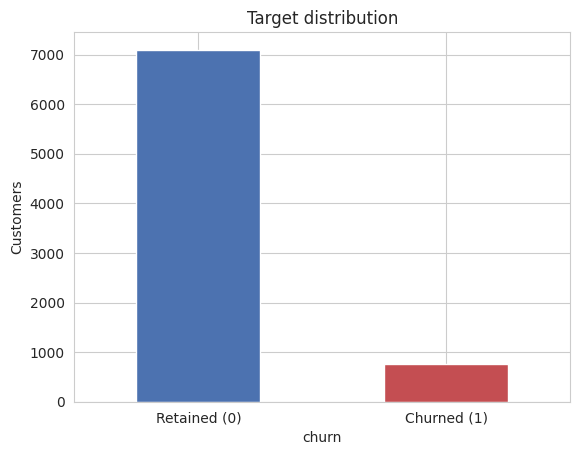

In [5]:
df = customer.merge(churn, on="id", how="inner")
print("Merged shape:", df.shape)
print("Duplicate ids:", df["id"].duplicated().sum())

rate = df["churn"].mean()
print(f"Churn rate: {rate:.2%}  (imbalanced - about 1 in 10 customers churn)")

ax = df["churn"].value_counts().sort_index().plot(kind="bar", color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["Retained (0)", "Churned (1)"], rotation=0)
ax.set_title("Target distribution"); ax.set_ylabel("Customers")
plt.show()

In [6]:
missing = (df.isna().mean() * 100).sort_values(ascending=False)
missing[missing > 0].round(1).to_frame("% missing")

,% missing
campaign_disc_ele,100.0
forecast_base_bill_year,77.6
forecast_bill_12m,77.6
forecast_base_bill_ele,77.6
forecast_cons,77.6
date_first_activ,77.6
activity_new,58.6
channel_sales,26.4
date_modif_prod,1.0
forecast_price_energy_p2,0.8


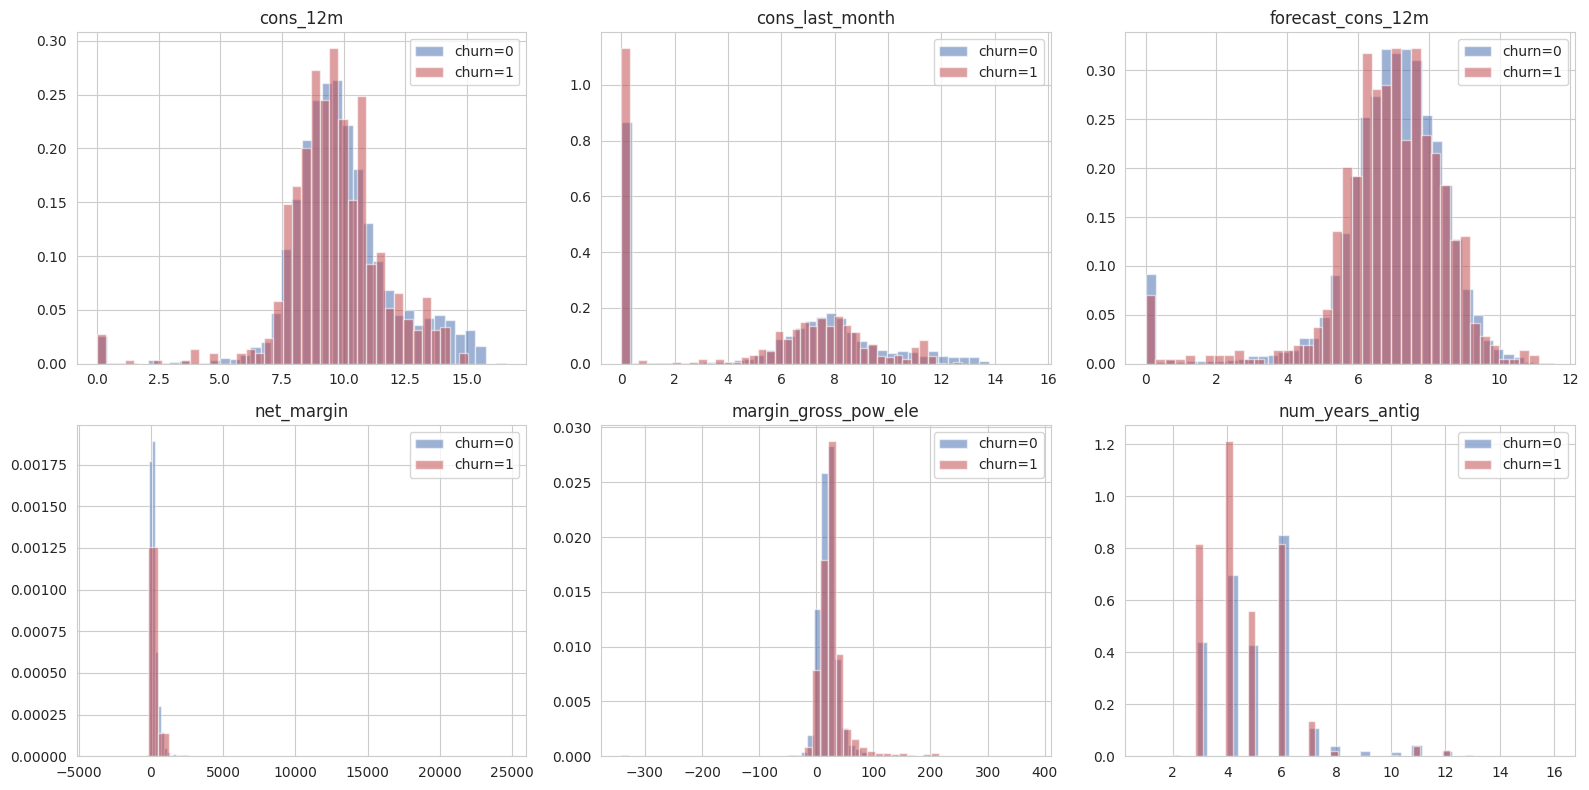

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), ["cons_12m", "cons_last_month", "forecast_cons_12m",
                                  "net_margin", "margin_gross_pow_ele", "num_years_antig"]):
    for label, color in [(0, "#4C72B0"), (1, "#C44E52")]:
        vals = df.loc[df["churn"] == label, col].dropna()
        if col.startswith(("cons", "forecast_cons")):
            vals = np.log1p(vals.clip(lower=0))
        ax.hist(vals, bins=40, alpha=0.55, density=True, label=f"churn={label}", color=color)
    ax.set_title(col); ax.legend()
plt.tight_layout(); plt.show()

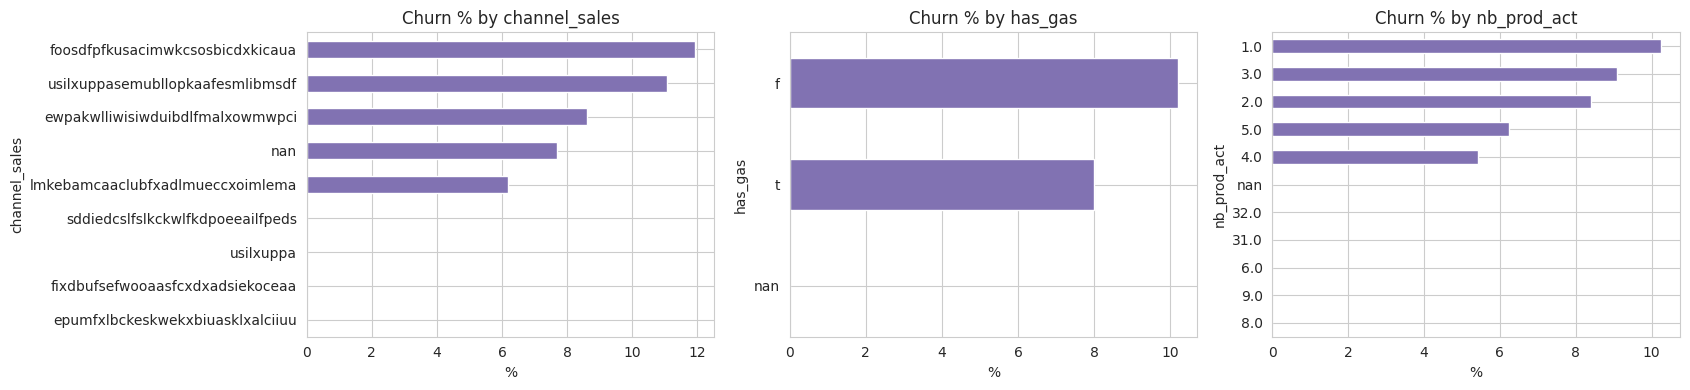

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, col in zip(axes, ["channel_sales", "has_gas", "nb_prod_act"]):
    df.groupby(col, dropna=False)["churn"].mean().mul(100).sort_values().plot(kind="barh", ax=ax, color="#8172B2")
    ax.set_title(f"Churn % by {col}"); ax.set_xlabel("%")
plt.tight_layout(); plt.show()

## 3. Feature engineering

**Price features** - customers are sensitive to price changes, so for each customer we summarise the monthly price history: mean, std, and the change between the last and first month (and between the last two months).

**Date features** - convert contract dates into durations (tenure, months until contract end, months since last renewal / product modification).

In [9]:
price["price_date"] = pd.to_datetime(price["price_date"])
price = price.sort_values(["id", "price_date"])
price_cols = ["price_p1_var", "price_p2_var", "price_p3_var",
              "price_p1_fix", "price_p2_fix", "price_p3_fix"]

price[price_cols] = price.groupby("id")[price_cols].transform(lambda s: s.ffill().bfill())

agg = price.groupby("id")[price_cols].agg(["mean", "std", "first", "last"])
agg.columns = [f"{c}_{s}" for c, s in agg.columns]

for c in price_cols:
    agg[f"{c}_change"] = agg[f"{c}_last"] - agg[f"{c}_first"]

last2 = price.groupby("id").tail(2).copy()
mom = last2.groupby("id")[price_cols].diff().dropna(how="all")
mom["id"] = last2.loc[mom.index, "id"]
mom = mom.set_index("id").add_suffix("_mom_delta")
agg = agg.join(mom)

mean_p = price.groupby("id")[price_cols].mean()
agg["var_p1_p2_gap"] = mean_p["price_p1_var"] - mean_p["price_p2_var"]
agg["var_p2_p3_gap"] = mean_p["price_p2_var"] - mean_p["price_p3_var"]
agg["fix_p1_p2_gap"] = mean_p["price_p1_fix"] - mean_p["price_p2_fix"]

agg = agg.drop(columns=[c for c in agg.columns if c.endswith(("_first", "_last"))]).reset_index()
print(agg.shape)
agg.head()

(1789, 28)


,id,price_p1_var_mean,price_p1_var_std,price_p2_var_mean,price_p2_var_std,price_p3_var_mean,price_p3_var_std,price_p1_fix_mean,price_p1_fix_std,price_p2_fix_mean,...,price_p3_fix_change,price_p1_var_mom_delta,price_p2_var_mom_delta,price_p3_var_mom_delta,price_p1_fix_mom_delta,price_p2_fix_mom_delta,price_p3_fix_mom_delta,var_p1_p2_gap,var_p2_p3_gap,fix_p1_p2_gap
0,002b3009d069858b471918402fb237b7,0.104044,0.002984,0.092514,0.001604,0.065678,0.0,59.173468,0.000000e+00,36.490689,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.011530,0.026836,22.682779
1,0030bd55614c2c5e693e04b64faa6445,0.167797,0.001337,0.086114,0.001997,0.000000,0.0,44.355820,9.284205e-02,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.081683,0.086114,44.355820
2,003e7fcd19e10f5114c29ce4a6997ba0,0.157671,0.023459,0.000000,0.000000,0.000000,0.0,44.883450,6.480625e-01,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.157671,0.000000,44.883450
3,005a1ca83d28ef9fe6b50db90fab2e6a,0.169388,0.001535,0.087706,0.001550,0.000000,0.0,44.355820,9.284205e-02,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.081682,0.087706,44.355820
4,0060e975b0d00bfe39fd2da5a36aefe9,0.165771,0.002383,0.084455,0.000388,0.000000,0.0,44.266930,6.179144e-07,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.081315,0.084455,44.266930


In [10]:
data = df.merge(agg, on="id", how="left")

date_cols = ["date_activ", "date_end", "date_first_activ", "date_modif_prod", "date_renewal"]
for c in date_cols:
    data[c] = pd.to_datetime(data[c], errors="coerce")

ref_date = pd.Timestamp("2016-01-01")
months = lambda a, b: (a - b).dt.days / 30.44

data["tenure_months"]            = months(ref_date, data["date_activ"])
data["months_to_contract_end"]   = months(data["date_end"], ref_date)
data["contract_length_months"]   = months(data["date_end"], data["date_activ"])
data["months_since_renewal"]     = months(ref_date, data["date_renewal"])
data["months_since_prod_modif"]  = months(ref_date, data["date_modif_prod"])
data["activ_month"]              = data["date_activ"].dt.month
data["end_month"]                = data["date_end"].dt.month
data["renewal_month"]            = data["date_renewal"].dt.month

eps = 1e-6
data["cons_last_month_ratio"]   = data["cons_last_month"] / (data["cons_12m"] + eps)
data["forecast_vs_actual_cons"] = data["forecast_cons_12m"] / (data["cons_12m"] + eps)
data["margin_per_kwh"]          = data["net_margin"] / (data["cons_12m"] + eps)
data["margin_gap_gross_net"]    = data["margin_gross_pow_ele"] - data["margin_net_pow_ele"]

data = data.drop(columns=date_cols)
print(data.shape)

(7867, 67)


## 4. Preprocessing

In [11]:
miss = data.isna().mean()
drop_cols = miss[miss > 0.60].index.tolist()
print("Dropping (>60% missing):", drop_cols)
data = data.drop(columns=drop_cols)

data["has_gas"] = data["has_gas"].map({"t": 1, "f": 0})

cat_low  = ["channel_sales"]
cat_high = ["activity_new", "origin_up"]

for c in cat_high:
    freq = data[c].value_counts(normalize=True)
    data[c + "_freq"] = data[c].map(freq).fillna(0)
data = data.drop(columns=cat_high)

data["channel_sales"] = data["channel_sales"].fillna("missing")
data = pd.get_dummies(data, columns=cat_low, prefix="channel", dtype=int)

data = data.replace([np.inf, -np.inf], np.nan)

X = data.drop(columns=["id", "churn"])
y = data["churn"]
print("Features:", X.shape[1], "| rows:", X.shape[0])

Dropping (>60% missing): ['campaign_disc_ele', 'forecast_base_bill_ele', 'forecast_base_bill_year', 'forecast_bill_12m', 'forecast_cons', 'price_p1_var_mean', 'price_p1_var_std', 'price_p2_var_mean', 'price_p2_var_std', 'price_p3_var_mean', 'price_p3_var_std', 'price_p1_fix_mean', 'price_p1_fix_std', 'price_p2_fix_mean', 'price_p2_fix_std', 'price_p3_fix_mean', 'price_p3_fix_std', 'price_p1_var_change', 'price_p2_var_change', 'price_p3_var_change', 'price_p1_fix_change', 'price_p2_fix_change', 'price_p3_fix_change', 'price_p1_var_mom_delta', 'price_p2_var_mom_delta', 'price_p3_var_mom_delta', 'price_p1_fix_mom_delta', 'price_p2_fix_mom_delta', 'price_p3_fix_mom_delta', 'var_p1_p2_gap', 'var_p2_p3_gap', 'fix_p1_p2_gap']
Features: 41 | rows: 7867


## 5. Train / test split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=RANDOM_STATE)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Train {X_train.shape} | Test {X_test.shape} | scale_pos_weight = {scale_pos_weight:.2f}")

Train (6293, 41) | Test (1574, 41) | scale_pos_weight = 9.22


## 6. Baseline XGBoost model


In [13]:
base = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    early_stopping_rounds=50,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
base.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
print("Best iteration:", base.best_iteration)

def evaluate(model, X, y, threshold=0.5, name=""):
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= threshold).astype(int)
    res = {
        "model": name, "threshold": threshold,
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred),
        "f1": f1_score(y, pred),
        "roc_auc": roc_auc_score(y, proba),
        "pr_auc": average_precision_score(y, proba),
    }
    return res

pd.DataFrame([evaluate(base, X_test, y_test, name="baseline")]).round(4)

Best iteration: 253


,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,baseline,0.5,0.8628,0.3086,0.3247,0.3165,0.6664,0.2726


## 7. Hyperparameter tuning (randomized search, stratified 5-fold CV)

In [14]:
param_dist = {
    "n_estimators":      [200, 400, 600],
    "learning_rate":     [0.01, 0.03, 0.05, 0.1],
    "max_depth":         [3, 4, 5, 6, 8],
    "min_child_weight":  [1, 3, 5, 10],
    "subsample":         [0.6, 0.8, 1.0],
    "colsample_bytree":  [0.5, 0.7, 0.9],
    "gamma":             [0, 0.1, 0.5, 1],
    "reg_alpha":         [0, 0.1, 1],
    "reg_lambda":        [1, 2, 5],
}

search = RandomizedSearchCV(
    xgb.XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric="auc",
                      random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=25,
    scoring="roc_auc",
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE,
    n_jobs=1, verbose=1,
)
search.fit(X_train, y_train)

print("Best CV ROC-AUC:", round(search.best_score_, 4))
print("Best params:", search.best_params_)
best = search.best_estimator_

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best CV ROC-AUC: 0.6716
Best params: {'subsample': 1.0, 'reg_lambda': 2, 'reg_alpha': 1, 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.5}


## 8. Evaluation on the held-out test set

In [15]:
results = pd.DataFrame([
    evaluate(base, X_test, y_test, name="baseline"),
    evaluate(best, X_test, y_test, name="tuned"),
]).round(4)
results

,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,baseline,0.5,0.8628,0.3086,0.3247,0.3165,0.6664,0.2726
1,tuned,0.5,0.7541,0.1974,0.4935,0.2820,0.6878,0.2755


              precision    recall  f1-score   support

    Retained       0.93      0.78      0.85      1420
     Churned       0.20      0.49      0.28       154

    accuracy                           0.75      1574
   macro avg       0.57      0.64      0.57      1574
weighted avg       0.86      0.75      0.80      1574



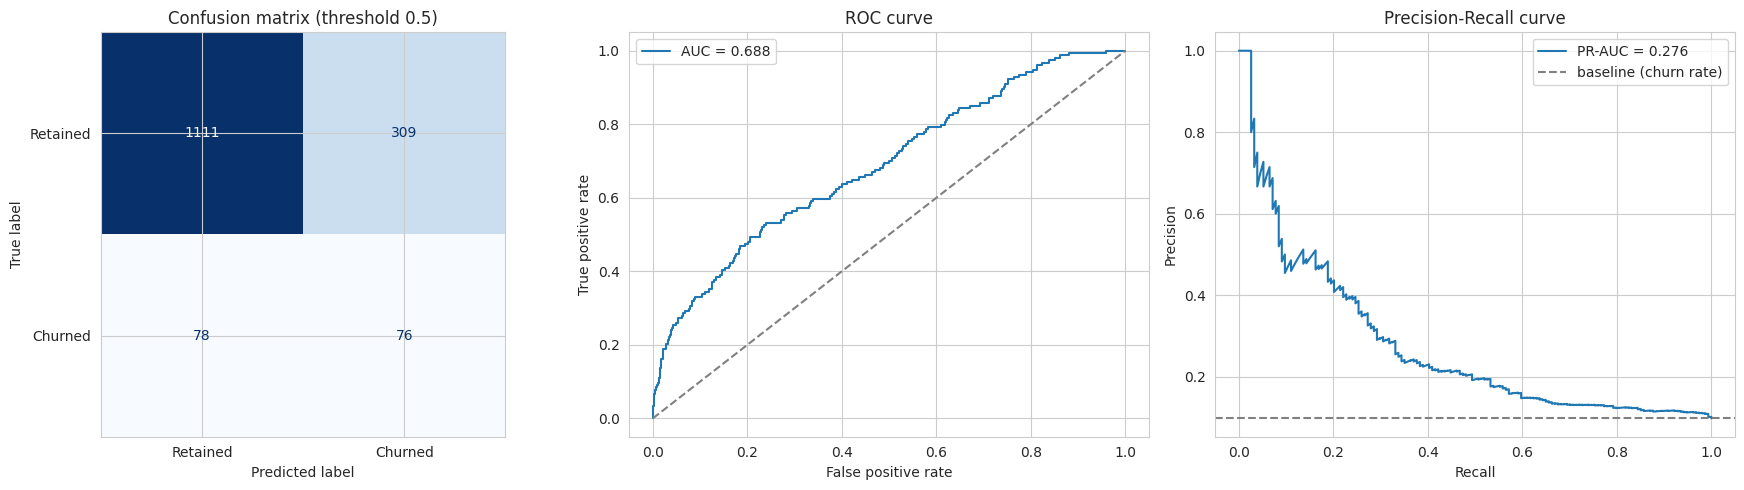

In [16]:
proba = best.predict_proba(X_test)[:, 1]
pred  = (proba >= 0.5).astype(int)
print(classification_report(y_test, pred, target_names=["Retained", "Churned"]))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=["Retained", "Churned"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion matrix (threshold 0.5)")

fpr, tpr, _ = roc_curve(y_test, proba)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, proba):.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="grey")
axes[1].set(xlabel="False positive rate", ylabel="True positive rate", title="ROC curve"); axes[1].legend()

p, r, _ = precision_recall_curve(y_test, proba)
axes[2].plot(r, p, label=f"PR-AUC = {average_precision_score(y_test, proba):.3f}")
axes[2].axhline(y_test.mean(), ls="--", color="grey", label="baseline (churn rate)")
axes[2].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall curve"); axes[2].legend()
plt.tight_layout(); plt.show()

### Choosing a decision threshold
The default 0.5 cut-off is rarely optimal for imbalanced churn data. Pick the threshold that matches the business goal - e.g. maximise F1, or favour recall if missing a churner is more costly than a wasted retention offer.

Threshold maximising F1: 0.57  (F1 = 0.304)


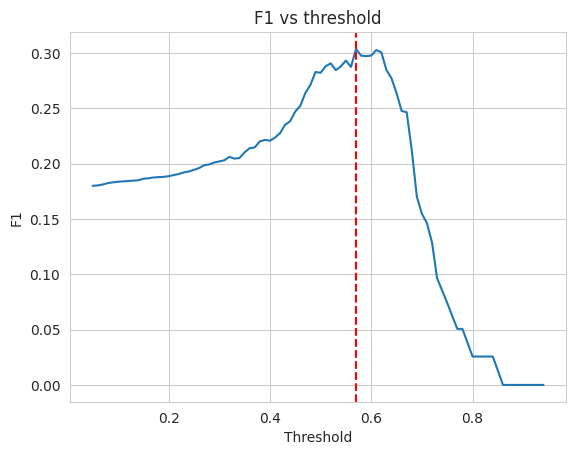

,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,tuned @0.5,0.50,0.7541,0.1974,0.4935,0.2820,0.6878,0.2755
1,tuned @0.57,0.57,0.8513,0.2802,0.3312,0.3036,0.6878,0.2755


In [17]:
thresholds = np.arange(0.05, 0.95, 0.01)
f1s = [f1_score(y_test, (proba >= t).astype(int)) for t in thresholds]
best_t = thresholds[int(np.argmax(f1s))]
print(f"Threshold maximising F1: {best_t:.2f}  (F1 = {max(f1s):.3f})")

plt.plot(thresholds, f1s); plt.axvline(best_t, color="red", ls="--")
plt.xlabel("Threshold"); plt.ylabel("F1"); plt.title("F1 vs threshold"); plt.show()

pd.DataFrame([evaluate(best, X_test, y_test, 0.5, "tuned @0.5"),
              evaluate(best, X_test, y_test, best_t, f"tuned @{best_t:.2f}")]).round(4)

## 9. Feature importance & interpretation

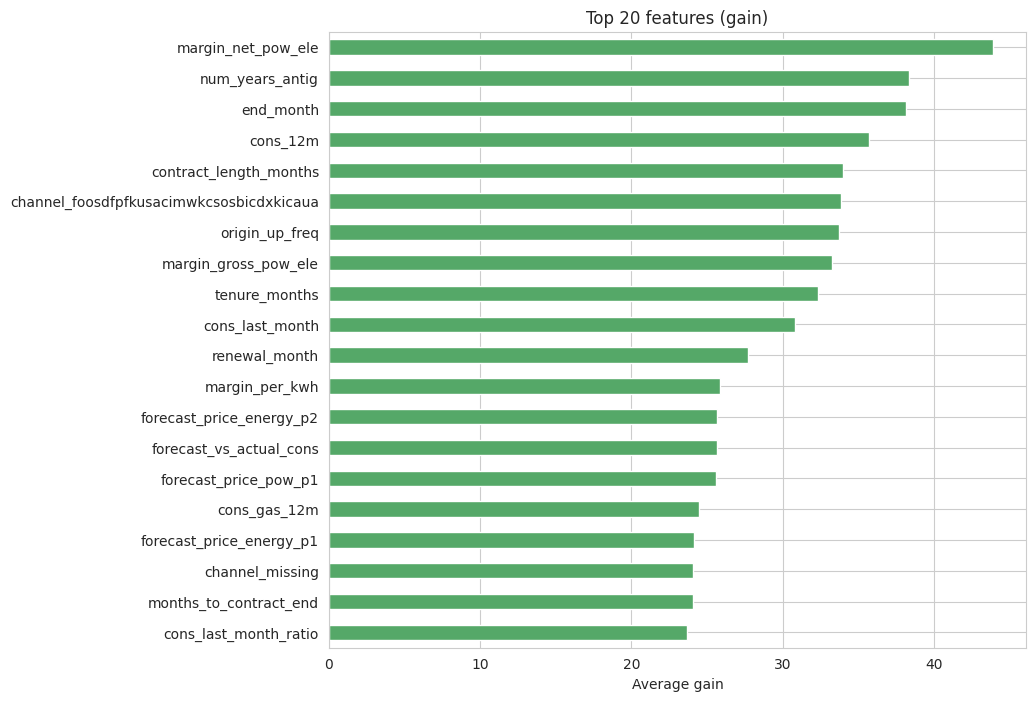

In [18]:
imp = pd.Series(best.get_booster().get_score(importance_type="gain")).sort_values(ascending=False)
top = imp.head(20)[::-1]
top.plot(kind="barh", figsize=(9, 8), color="#55A868")
plt.title("Top 20 features (gain)"); plt.xlabel("Average gain"); plt.show()

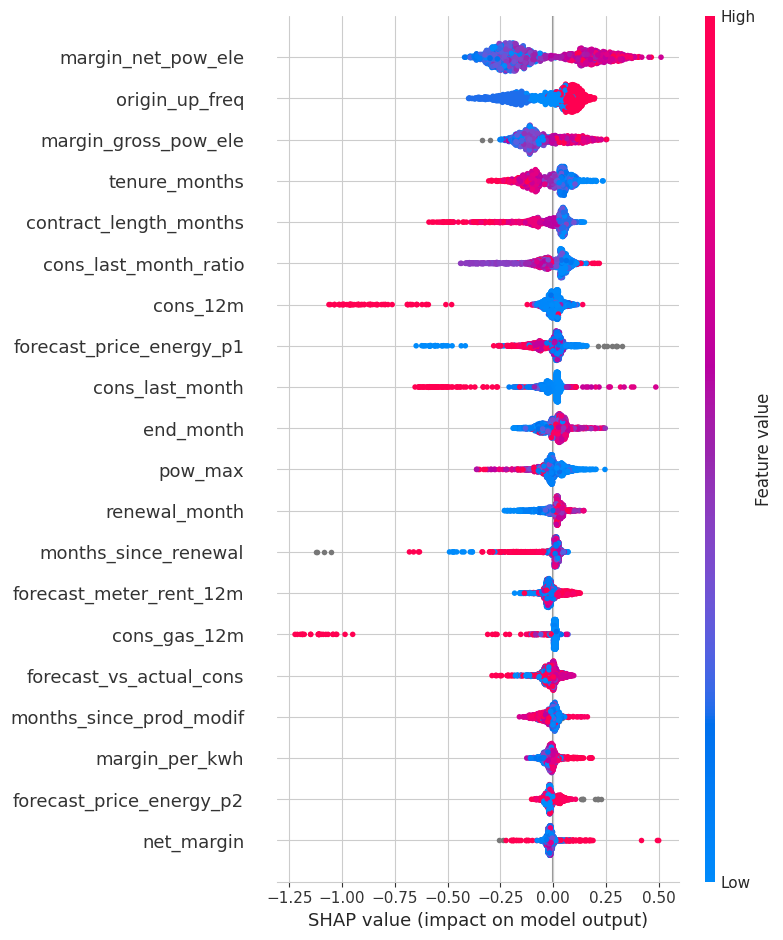

In [19]:
try:
    import shap
    explainer = shap.TreeExplainer(best)
    sample = X_test.sample(min(2000, len(X_test)), random_state=RANDOM_STATE)
    shap_values = explainer.shap_values(sample)
    shap.summary_plot(shap_values, sample, max_display=20)
except ImportError:
    print("shap not installed - run `pip install shap` to see this plot.")

## 10. Score customers & identify high-risk ones

In [20]:
scored = data[["id"]].copy()
scored["churn_probability"] = best.predict_proba(X)[:, 1]
scored["actual_churn"] = y.values
scored["risk_band"] = pd.cut(scored["churn_probability"], [0, 0.3, 0.6, 1.0],
                             labels=["Low", "Medium", "High"], include_lowest=True)

print(scored["risk_band"].value_counts())
scored.sort_values("churn_probability", ascending=False).head(15)

risk_band
Medium    5677
Low       1413
High       777
Name: count, dtype: int64


,id,churn_probability,actual_churn,risk_band
2484,e589f9f22d0a542fb194c3b6cd43ae1d,0.913754,1,High
4669,1c9a69e3b4388cd85a8bcc57ecb18f9f,0.903300,1,High
1089,17427fa5d523c73f93cb42349f11db6a,0.900040,1,High
4758,a5ff2a8be36ecc99d829e19c2a6eab82,0.893340,1,High
5310,3fbd7246c9dd91d4d3ec5418e13cc1b7,0.883959,1,High
4258,bf46164265e7481110228e0d28f336de,0.873063,1,High
6025,fa9785290fbc62849a5133a18f1db6f0,0.866028,1,High
83,3143ff0dec9bb97876c726e42b5a66c6,0.859938,1,High
2520,fc3de6b2dd08a6660d7ffcd88331b1db,0.854186,1,High
7546,2642949996db63cc3da050f81a069722,0.847632,1,High


In [21]:
t = pd.DataFrame({"y": y_test.values, "p": proba})
t["decile"] = pd.qcut(t["p"].rank(method="first", ascending=False), 10, labels=range(1, 11))
lift = t.groupby("decile")["y"].agg(["sum", "mean"]).rename(columns={"sum": "churners", "mean": "churn_rate"})
lift["lift"] = lift["churn_rate"] / t["y"].mean()
lift.round(3)

,churners,churn_rate,lift
decile,,,
1,47,0.297,3.040
2,20,0.127,1.302
3,16,0.102,1.042
4,10,0.063,0.647
5,11,0.070,0.716
6,17,0.108,1.107
7,10,0.063,0.647
8,13,0.083,0.846
9,9,0.057,0.586


## 11. Save the model and predictions

In [22]:
best.save_model("churn_xgboost_model.json")
scored.to_csv("churn_predictions.csv", index=False)
print("Saved churn_xgboost_model.json and churn_predictions.csv")

Saved churn_xgboost_model.json and churn_predictions.csv
